In [3]:
# === Core Python ===
import os
import glob
import collections
import cftime
import datetime
from datetime import datetime
from typing import Tuple, Dict, Optional

import cmocean

# === Numerical & Data Handling ===
import numpy as np
import numpy.ma as ma
import pandas as pd
import xarray as xr
import xcdat as xcd
import xskillscore as xs
from xskillscore import rmse, pearson_r

import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import matplotlib.dates as mdates
import matplotlib.animation as animation

from MJOPrecDiag import HovmollerPrecipAnalyzer

/qfs/people/zhan391/.conda/envs/e3sm_analysis/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [4]:
data_dict = {
    'CTRLEN10': {
        'seg1': {
            'path': '/compyfs/zhan391/v3_dart_cda_scratch/CTRLEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/post/atm/180x360_aave/ts/daily',
            'template': 'FLUT.%(ensemble)s.2011.nc',
            'period': '20111201-20121231',
            'fscale': 86400000.0,
            'frequency': 'daily',
            'nens': 10
        },
        'seg2': {
            'path': '/compyfs/zhan391/v3_dart_cda_scratch/CTRLEN10_15day_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/post/atm/180x360_aave/ts/daily',
            'template': 'FLUT.%(ensemble)s.2012.nc',
            'period': '20120101-20120229',
            'fscale': 86400000.0,
            'frequency': 'daily',
            'nens': 10
        }
    },
    'CAPTEN10': {
        'seg1': {
            'path': '/compyfs/zhan391/v3_dart_cda_scratch/CTRLEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/post/atm/180x360_aave/ts/daily',
            'template': 'FLUT.%(ensemble)s.2011.nc',
            'period': '20111201-20121231',
            'fscale': 86400000.0,
            'frequency': 'daily',
            'nens': 10
        },
        'seg2': {
            'path': '/compyfs/zhan391/v3_dart_cda_scratch/CAPTEN10_15day_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/post/atm/180x360_aave/ts/daily',
            'template': 'FLUT.%(ensemble)s.2012.nc',
            'period': '20120101-20120229',
            'fscale': 86400000.0,
            'frequency': 'daily',
            'nens': 10
        }
    },
    'DARTEN20': {
        'seg1': {
            'path': '/compyfs/zhan391/v3_dart_cda_scratch/DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/post/atm/180x360_aave/ts/daily',
            'template': 'FLUT.%(ensemble)s.2011.nc',
            'period': '20111201-20121231',
            'fscale': 86400000.0,
            'frequency': 'daily',
            'nens': 20
        },
        'seg2': {
            'path': '/compyfs/zhan391/v3_dart_cda_scratch/DARTEN20_15day_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/post/atm/180x360_aave/ts/daily',
            'template': 'FLUT.%(ensemble)s.2012.nc',
            'period': '20120101-20120229',
            'fscale': 86400000.0,
            'frequency': 'daily',
            'nens': 20
        }
    },
    'DARTEN40': {
        'seg1': {
            'path': '/compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/post/atm/180x360_aave/ts/daily',
            'template': 'FLUT.%(ensemble)s.2011.nc',
            'period': '20111201-20121231',
            'fscale': 86400000.0,
            'frequency': 'daily',
            'nens': 40
        },
        'seg2': {
            'path': '/compyfs/zhan391/v3_dart_cda_scratch/DARTEN40_15day_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/archive/post/atm/180x360_aave/ts/daily',
            'template': 'FLUT.%(ensemble)s.2012.nc',
            'period': '20120101-20120229',
            'fscale': 86400000.0,
            'frequency': 'daily',
            'nens': 40
        }
    }
}


[INFO] Running MJO analysis for CTRLEN10

[INFO] Processing CTRLEN10 with 10 ensemble member(s)...
Period in file dictionary 20111201-20121231
Parsed time range: 2011-12-01 00:00:00 to 2012-12-31 23:59:59
Selected period (20111201-20121231): got 2011-12-01 00:00:00 to 2011-12-31 00:00:00
Period in file dictionary 20120101-20120229
Parsed time range: 2012-01-01 00:00:00 to 2012-02-29 23:59:59
Selected period (20120101-20120229): got 2012-01-01 00:00:00 to 2012-02-29 00:00:00
Customized period: 20111201-20120229
Parsed time range: 2011-12-01 00:00:00 to 2012-02-29 23:59:59
Extracting time range: 2011-12-01 00:00:00 to 2012-02-29 00:00:00
Period in file dictionary 20111201-20121231
Parsed time range: 2011-12-01 00:00:00 to 2012-12-31 23:59:59
Selected period (20111201-20121231): got 2011-12-01 00:00:00 to 2011-12-31 00:00:00
Period in file dictionary 20120101-20120229
Parsed time range: 2012-01-01 00:00:00 to 2012-02-29 23:59:59
Selected period (20120101-20120229): got 2012-01-01 00:00:0

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

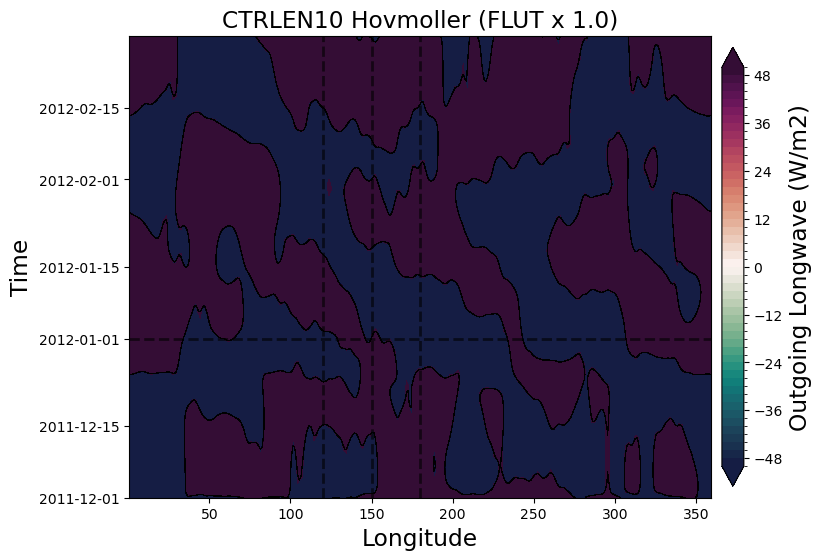

In [10]:
if __name__ == "__main__":
    top_path = "/compyfs/zhan391/v3_dart_cda_scratch"
    out_path = "/compyfs/zhan391/v3_dart_cda_scratch/diag_dart"
    fig_path = "/qfs/people/zhan391/e3sm_dart_work/analysis/diagnostic/figures/mjo_analysis"
    rmm_dir = "/compyfs/zhan391/acme_init/Observations/MJO_INDEX"
    compset = "F20TR"
    resolution = "ne30pg2_r05_IcoswISC30E3r5"
    machine = "compy"
    exp_base = f"{compset}_{resolution}_{machine}"

    os.makedirs(out_path, exist_ok=True)
    os.makedirs(fig_path, exist_ok=True)

    region_dict = {"Tropics": [-10, 10]}
    
    frequency = "daily"
    region =  "Tropics"
    dt_hours  = 24
    time_start = "20111201"
    time_end = "20120229"
    
    varname = 'FLUT'
    var_dict = {
        'FLUT': {'alias':'Outgoing Longwave', 'units': "W/m2"} 
    }
    mjo_filter = True #True  #False #20-96day filtering
    remove_clim = True #True #False 
    
    if not mjo_filter and not remove_clim:
        vmin = 0.0 
        vmax = 20.0 
        nlevs = 21
        cmap = cmocean.cm.deep
        clevs = [0,0.1,0.5,1,2,4,6,8,10,15,20]
        fig_key = "nfilt_raw"
    elif mjo_filter: 
        vmin = -50
        vmax = 50 
        nlevs = 51
        cmap = cmocean.cm.curl #plt.cm.bwr
        clevs = None #[-10,-8,-6,-4,-2,-1,-0.5,-0.1,0.1,0.5,1,2,3,4,6,8,10]
        fig_key = "mjo_filter"
    elif remove_clim:
        vmin = -50
        vmax = 50
        nlevs = 51
        cmap = cmocean.cm.curl #plt.cm.bwr
        clevs = None #[] [-15,-10,-5,-3,-2,-1,-0.5,-0.2,0.2,0.5,1,2,3,5,10,15]
        fig_key = "remove_clim"
        
    model_list = list(data_dict.keys())

    analyzer = HovmollerPrecipAnalyzer(
        data_dict=data_dict,
        varname=varname,
        var_info=var_dict[varname],
        lat_bounds=region_dict[region],
        dt_hours=dt_hours,
        mjo_filter= mjo_filter,
        remove_clim=remove_clim,
        rmm_path=rmm_dir,
        frequency= frequency, 
        time_start = time_start, 
        time_end = time_end,
        fontz=14
    )
    
    for exp in model_list:
        print(f"\n[INFO] Running MJO analysis for {exp}")
        output_dir = os.path.join(fig_path, f"mjo_{exp}")
        os.makedirs(output_dir, exist_ok=True)
        
        figfile = os.path.join(output_dir, f"hovmoller_mjo_{varname}_{exp}_{fig_key}.pdf")
        analyzer.generate_hovmoller(
            exp_key=exp,
            savepath=figfile,
            filter_by_amplitude=True,
            xlabel="Longitude",
            amp_thresh=1.0,
            overlay_phase=True,
            cmap=cmap,
            vmin=vmin, 
            vmax=vmax, 
            nlevs=nlevs,
            clevs=clevs 
        )
        


In [4]:
if __name__ == "__main__":
    top_path = "/compyfs/zhan391/v3_dart_cda_scratch"
    out_path = "/compyfs/zhan391/v3_dart_cda_scratch/diag_dart"
    fig_path = "/qfs/people/zhan391/e3sm_dart_work/analysis/diagnostic/figures/mjo_analysis"
    rmm_dir = "/compyfs/zhan391/acme_init/Observations/MJO_INDEX"
    compset = "F20TR"
    resolution = "ne30pg2_r05_IcoswISC30E3r5"
    machine = "compy"
    exp_base = f"{compset}_{resolution}_{machine}"

    os.makedirs(out_path, exist_ok=True)
    os.makedirs(fig_path, exist_ok=True)

    region = {"Tropics": [-20, 20]}
    
    frequency = "daily"
    time_start = "2011-12-01"
    time_end = "2012-02-29"
    
    varname = "PRECT"
    vmin    = -5
    vmax    = 5 
    nlevs   = 11
    
    model_list = list(data_dict.keys())

    analyzer = HovmollerPrecipAnalyzer(
        data_dict=data_dict,
        varname=varname,
        lat_bounds=region["Tropics"],
        dt_hours=24,
        rmm_path=rmm_dir,
        time_start = time_start, 
        time_end = time_end
    )

    analyzer.plot_rmm_phase_space(
        start=time_start, 
        end=time_end,
        amp_thresh=1.0,
        savepath=os.path.join(
            fig_path, 
            "rmm_phase_space.pdf"
        )
    )
    
    for exp in model_list:
        print(f"\n[INFO] Running MJO analysis for {exp}")
        output_dir = os.path.join(fig_path, f"mjo_{exp}")
        os.makedirs(output_dir, exist_ok=True)
        
        comps = analyzer.compute_phase_composites(exp)
        figname = os.path.join(output_dir, f"phase_composite_mjo_{exp}.pdf")
        analyzer.plot_phase_composites(comps,figname)


TypeError: HovmollerPrecipAnalyzer.__init__() missing 1 required positional argument: 'var_info'